In [16]:
from pathlib import Path
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import shutil

Ustawienie na początku głównego folderu, żeby dalej używać ścieżek względnych.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

# Ścieżka do folderu na Google Drive
main_folder = Path("/content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<h3> 1. Wczytanie ścieżek </h3>


In [18]:
#ścieżki do naszych folderów (względne - 25Gy_expert są podfolderami w głównej ścieżce)
dir_expert1 = os.path.join(main_folder, "25Gy_expert1")
dir_expert2 = os.path.join(main_folder, "25Gy_expert2")
dir_expert3 = os.path.join(main_folder, "25Gy_expert3")


all_dirs = [dir_expert1, dir_expert2, dir_expert3] #typ: list
all_imgs = {} #typ: dictionary

#pętla z pętlami zagnieżdżonymi - by "przejść" przez wszystkie (pod)foldery i pliki z danym rozszerzeniem
for path in all_dirs:
    print(f"Przetwarzam: {path}")
    dir_imgs = {}

    for root, dirs, files in os.walk(path):
        for f in files:
            if f.lower().endswith('.png'):
                dir_imgs[f] = os.path.join(root, f)
    all_imgs[path] = dir_imgs


#wyświetlamy wynik
for s in all_dirs:
    print(f"Folder {s} zawiera {len(all_imgs[s])} zdjęć.")

print(type(all_dirs)) #jak nie znamy typu możemy sobie wyprintować jaki to typ

Przetwarzam: /content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1/25Gy_expert1
Przetwarzam: /content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1/25Gy_expert2
Przetwarzam: /content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1/25Gy_expert3
Folder /content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1/25Gy_expert1 zawiera 92 zdjęć.
Folder /content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1/25Gy_expert2 zawiera 92 zdjęć.
Folder /content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1/25Gy_expert3 zawiera 92 zdjęć.
<class 'list'>


<h3> 2. Sprawdzenie nazw - czy się zgadzają pomiędzy plikami </h3>

In [19]:
#tworzenie zbiorów nazw plików
names1 = set(all_imgs[dir_expert1].keys()) #typ: zbiór
names2 = set(all_imgs[dir_expert2].keys())
names3 = set(all_imgs[dir_expert3].keys())

#pula wspólnych nazw -> wykorzystujemy & (AND) -> iloczyn logiczny -> dany element MUSI znajdować się we WSZYSTKICH zbiorach
common_names = names1 & names2 & names3
#wszytskie możliwości -> wykorzystujemy | (OR) -> suma logiczna -> dany element MUSI znajdować się w PRZYNAJMNIEJ JEDNYM zbiorze
all_possibilities = names1 | names2 | names3

#wyświetlamy wynik
print("-" * 30)
print(f"Razem unikalnych zdjęć we wszystkich folderach: {len(all_possibilities)}")
print(f"Zdjęć posiadanych przez komplet ekspertów: {len(common_names)}")
print("-" * 30)


#pętla wyświetlająca braki lub informacje o komplecie
for i, expert_names in enumerate([names1, names2, names3], 1):
    missing_files = all_possibilities - expert_names
    if missing_files:
        print(f"Ekspert {i} nie ma plików ({len(missing_files)} szt.): {list(missing_files)[:5]}...")
    else:
        print(f"Ekspert {i} ma wszystkie zdjęcia.")


------------------------------
Razem unikalnych zdjęć we wszystkich folderach: 92
Zdjęć posiadanych przez komplet ekspertów: 92
------------------------------
Ekspert 1 ma wszystkie zdjęcia.
Ekspert 2 ma wszystkie zdjęcia.
Ekspert 3 ma wszystkie zdjęcia.


Przetwarzam 92 plików. Zapisuję na dysk...
CONV_fot_25Gy1_nr2.0_00018.png
CONV_fot_25Gy10_nr2.0_00028.png
CONV_fot_25Gy10_nr2.0_00015.png
CONV_fot_25Gy100_nr1.0_00010.png
CONV_fot_25Gy100_nr1.0_00016.png
CONV_fot_25Gy100_nr1.0_00024.png
CONV_fot_25Gy10_nr2.0_00034.png
CONV_fot_25Gy10_nr2.0_00029.png
CONV_fot_25Gy1_nr2.0_00025.png
CONV_fot_25Gy10_nr2.0_00019.png
CONV_fot_25Gy10_nr2.0_00017.png
CONV_fot_25Gy10_nr2.0_00002.png
CONV_fot_25Gy100_nr1.0_00013.png
CONV_fot_25Gy10_nr2.0_00025.png
CONV_fot_25Gy1_nr2.0_00015.png
CONV_fot_25Gy1_nr2.0_00012.png
CONV_fot_25Gy1_nr2.0_00028.png
CONV_fot_25Gy10_nr2.0_00027.png
CONV_fot_25Gy100_nr1.0_00027.png
CONV_fot_25Gy100_nr1.0_00023.png
CONV_fot_25Gy100_nr1.0_00028.png
CONV_fot_25Gy1_nr2.0_00024.png
CONV_fot_25Gy1_nr2.0_00002.png
CONV_fot_25Gy1_nr2.0_00011.png
CONV_fot_25Gy100_nr1.0_00021.png
CONV_fot_25Gy100_nr1.0_00004.png
CONV_fot_25Gy1_nr2.0_00007.png
CONV_fot_25Gy10_nr2.0_00013.png
CONV_fot_25Gy100_nr1.0_00001.png
CONV_fot_25Gy10_nr2.0_00006.

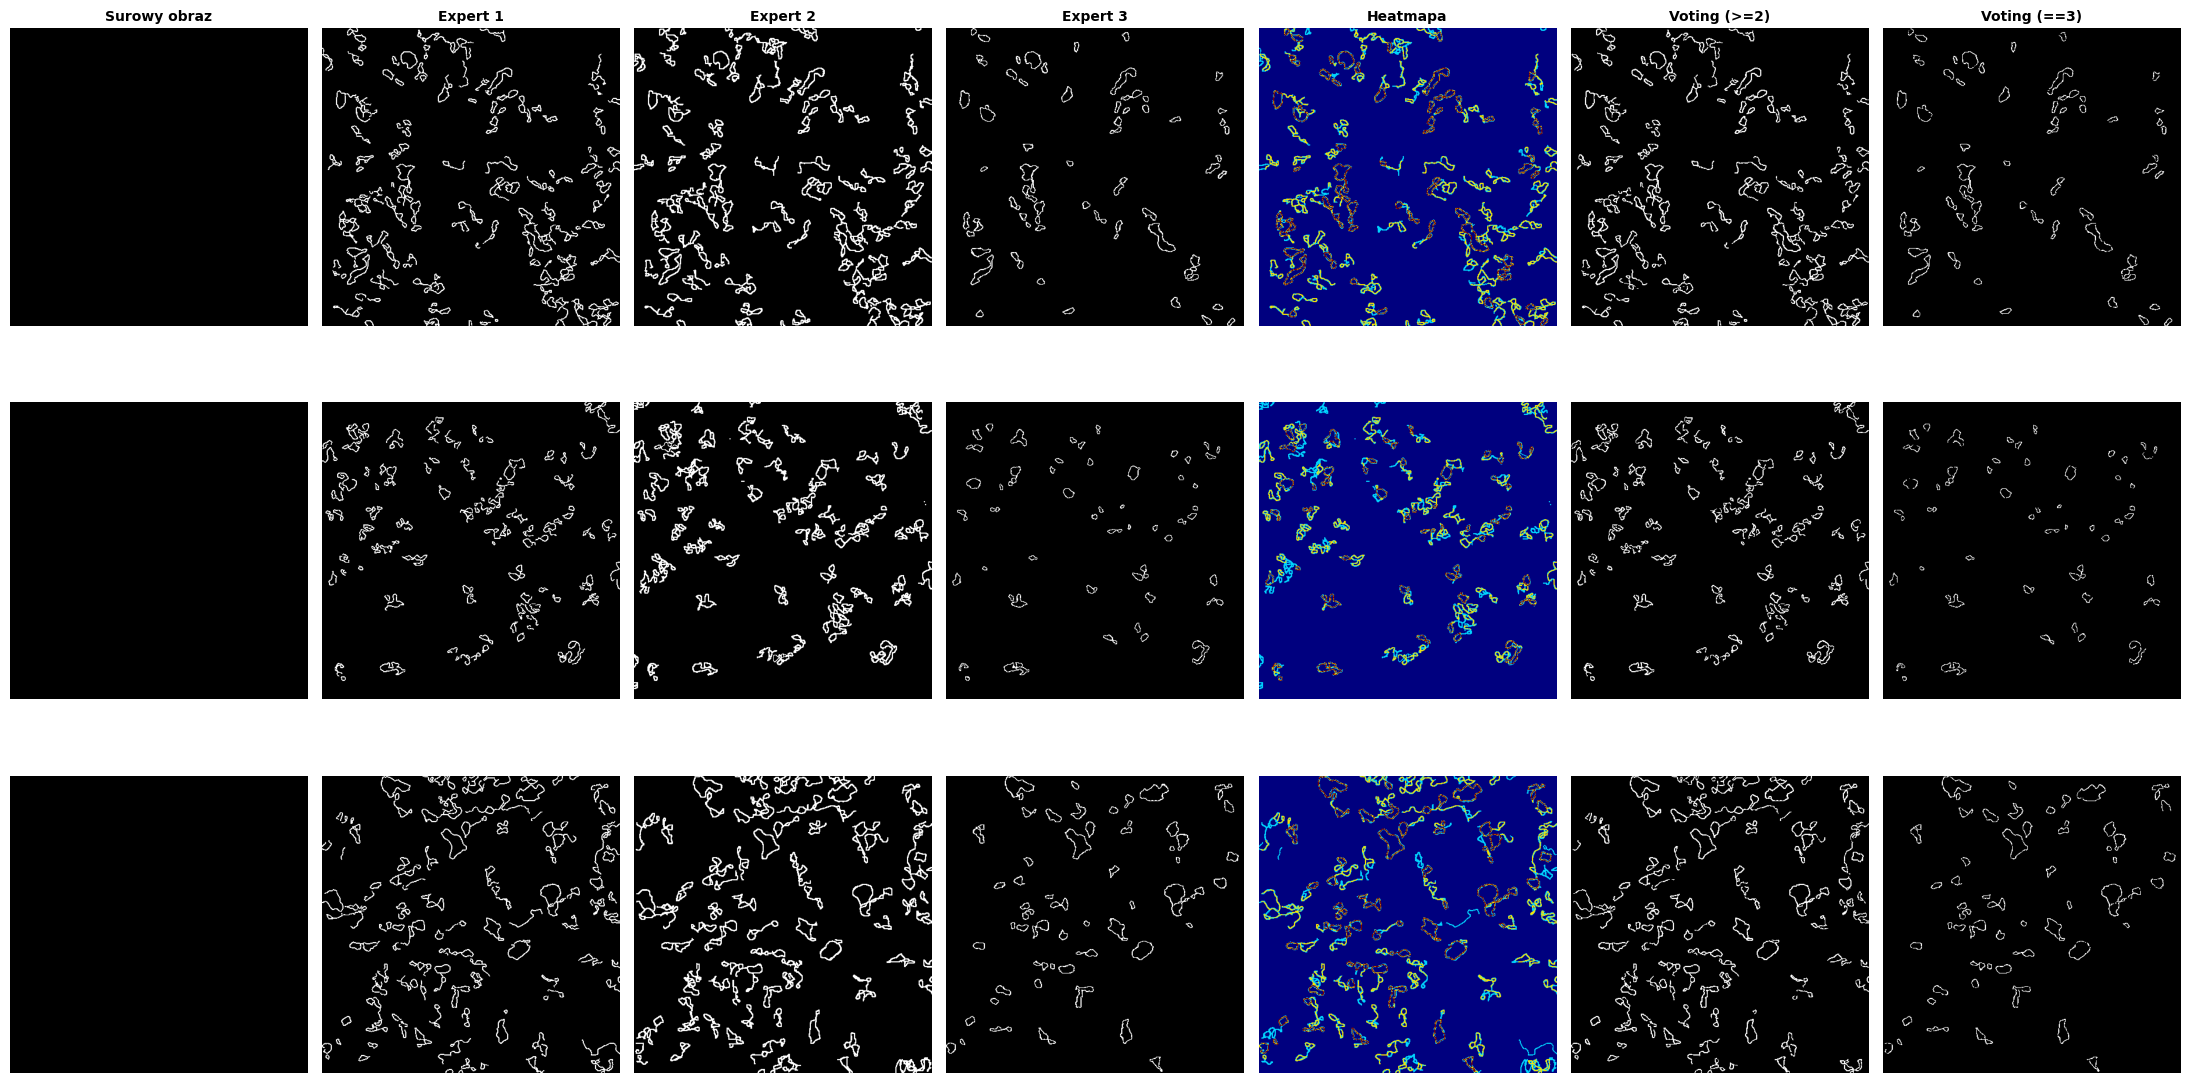

In [20]:
# Nowy folder na ostateczne maski
output_dir = os.path.join(main_folder, "final_masks")
os.makedirs(output_dir, exist_ok=True)

dir_raw_files = os.path.join(main_folder, "../CONV_mixed/25Gy_all")
random_files = random.sample(list(common_names), 3)
raw_map = {}
for root, dirs, files in os.walk(dir_raw_files):
    for f in files:
        if f.lower().endswith('.png'):
            raw_map[f] = os.path.join(root, f)


def get_binary_mask(img_path, target_shape=None):
    img = cv2.imread(img_path)

    # Przeskalowanie obrazu, jeśli podano wymiar docelowy
    if target_shape is not None:
        # OpenCV wymaga formatu (Szerokość, Wysokość) dla resize
        # Używamy INTER_NEAREST, by uniknąć rozmycia (chcemy tylko 0 i 255)
        img = cv2.resize(img, target_shape, interpolation=cv2.INTER_NEAREST)

    lower_red = np.array([0, 0, 150])
    upper_red = np.array([100, 100, 255])
    return cv2.inRange(img, lower_red, upper_red)


fig, axes = plt.subplots(3, 7, figsize=(22, 12))

# Zmienna do śledzenia aktualnego rzędu na wykresie
plot_row_idx = 0

print(f"Przetwarzam {len(common_names)} plików. Zapisuję na dysk...")

# Pętla po wszystkich plikach, a nie tylko wylosowanych
for filename in common_names:
    print(filename)
    p1 = all_imgs[dir_expert1][filename]
    p2 = all_imgs[dir_expert2][filename]
    p3 = all_imgs[dir_expert3][filename]

    # Pobieramy maski
    m1 = get_binary_mask(p1)
    target_wh = (m1.shape[1], m1.shape[0])

    m2 = get_binary_mask(p2, target_shape=target_wh)
    m3 = get_binary_mask(p3, target_shape=target_wh)

    # Konwersja na 0 i 1
    m1_bin = (m1 > 0).astype(np.uint8)
    m2_bin = (m2 > 0).astype(np.uint8)
    m3_bin = (m3 > 0).astype(np.uint8)

    # Sumowanie głosów ekspertów
    summed_masks = m1_bin + m2_bin + m3_bin

    # Decyzja: bierzemy pod uwagę piksele, gdzie min. 2 ekspertów się zgadza
    final_mask = (summed_masks >= 2).astype(np.uint8) * 255

    # 1. Zapis pliku na dysk (dla każdego pliku w pętli)
    save_path = os.path.join(output_dir, filename)
    cv2.imwrite(save_path, final_mask)

    # 2. Opcjonalna wizualizacja, tylko jeśli to jeden z 3 losowych plików
    if filename in random_files:
        raw_path = raw_map.get(filename)
        if raw_path and os.path.exists(raw_path):
            raw_img_bgr = cv2.imread(raw_path)
            raw_img = cv2.cvtColor(raw_img_bgr, cv2.COLOR_BGR2RGB)
            raw_img = cv2.resize(raw_img, target_wh)
        else:
            raw_img = np.zeros((target_wh[1], target_wh[0], 3), dtype=np.uint8)

        voting_thr3 = (summed_masks >= 3).astype(np.uint8) * 255

        titles = ['Surowy obraz', 'Expert 1', 'Expert 2', 'Expert 3', 'Heatmapa', 'Voting (>=2)', 'Voting (==3)']
        images = [raw_img, m1, m2, m3, summed_masks, final_mask, voting_thr3]

        for col, (img, title) in enumerate(zip(images, titles)):
            ax = axes[plot_row_idx, col]

            if title == 'Heatmapa':
                im = ax.imshow(img, cmap='jet', vmin=0, vmax=3)
            elif len(img.shape) == 2:
                ax.imshow(img, cmap='gray')
            else:
                ax.imshow(img)

            if plot_row_idx == 0:
                ax.set_title(title, fontweight='bold', fontsize=10)
            ax.axis('off')

        # Zwiększamy licznik rzędu po uzupełnieniu jednego z 3 obrazków
        plot_row_idx += 1

print(f"Gotowe! Maski zapisano w: {output_dir}")

# Rysowanie wykresu po zakończeniu pełnej pętli
plt.tight_layout()
plt.show()

In [21]:
dataset_dir = os.path.join(main_folder, "dataset_25Gy")

folders = [
    "train/images", "train/masks",
    "val/images", "val/masks"
]


for folder in folders:
    # Tworzymy pełną ścieżkę i używamy exist_ok=True, żeby nie wywaliło błędu przy ponownym uruchomieniu
    os.makedirs(os.path.join(dataset_dir, folder), exist_ok=True)

# 2. Przygotowanie listy wszystkich plików
# Zamieniamy zbiór (set) na listę, aby móc ją posortować i pomieszać
all_files = list(common_names)

# Sortowanie zapewnia powtarzalność przed losowaniem (dobre praktyki)
all_files.sort()

# Ustawiamy "ziarno" losowości (seed).
# Dzięki temu przy każdym uruchomieniu tego kodu pliki podzielą się dokładnie tak samo!
random.seed(42)

# Mieszamy pliki jak talię kart
random.shuffle(all_files)

# 3. Wyliczamy podział (np. 80% do treningu, 20% do walidacji)
split_ratio = 0.8
split_index = int(len(all_files) * split_ratio)

train_files = all_files[:split_index]
val_files = all_files[split_index:]

# 4. Funkcja pomocnicza do kopiowania plików we właściwe miejsca
def copy_dataset_files(file_list, split_name):
    for filename in file_list:
        # Kopiowanie obrazu surowego
        src_img = raw_map.get(filename) # Korzystamy z mapowania z poprzednich komórek
        if src_img and os.path.exists(src_img):
            dst_img = os.path.join(dataset_dir, split_name, "images", filename)
            shutil.copy(src_img, dst_img)

        # Kopiowanie ostatecznej maski
        # output_dir to zmienna z poprzedniego kroku (tam, gdzie zapisaliśmy maski "voting >= 2")
        src_mask = os.path.join(output_dir, filename)
        if os.path.exists(src_mask):
            dst_mask = os.path.join(dataset_dir, split_name, "masks", filename)
            shutil.copy(src_mask, dst_mask)

# 5. Uruchomienie kopiowania
print("-" * 40)
print(f"Tworzę zbiór TRENINGOWY: kopiuję {len(train_files)} plików...")
copy_dataset_files(train_files, "train")

print(f"Tworzę zbiór WALIDACYJNY: kopiuję {len(val_files)} plików...")
copy_dataset_files(val_files, "val")
print("-" * 40)
print(f"Struktura gotowa! Możesz sprawdzić folder: {dataset_dir}")

----------------------------------------
Tworzę zbiór TRENINGOWY: kopiuję 73 plików...
Tworzę zbiór WALIDACYJNY: kopiuję 19 plików...
----------------------------------------
Struktura gotowa! Możesz sprawdzić folder: /content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1/dataset_25Gy


### 3. Trenowanie prostego modelu do segmentacji (U-Net)

Użyjemy biblioteki TensorFlow/Keras do zbudowania i wytrenowania modelu. Najpierw zdefiniujemy funkcję pomocniczą do wczytywania danych w locie.

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

def load_and_preprocess(img_path, mask_path):
    # Wczytywanie obrazu
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [256, 256])

    # Wczytywanie maski
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.convert_image_dtype(mask, tf.float32)
    mask = tf.image.resize(mask, [256, 256])
    # Konwersja maski na binarną (0 lub 1)
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return img, mask

def get_dataset(split_name):
    img_dir = os.path.join(dataset_dir, split_name, "images")
    mask_dir = os.path.join(dataset_dir, split_name, "masks")

    filenames = sorted(os.listdir(img_dir))
    img_paths = [os.path.join(img_dir, f) for f in filenames]
    mask_paths = [os.path.join(mask_dir, f) for f in filenames]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(8).prefetch(tf.data.AUTOTUNE)

train_ds = get_dataset("train")
val_ds = get_dataset("val")

In [23]:
import tensorflow.keras.backend as K

def dice_loss(y_true, y_pred):
    # Funkcja Dice Loss jest lepsza dla rzadkich obiektów (cienkie linie plazmidów)
    numerator = 2 * tf.reduce_sum(y_true * y_pred)
    denominator = tf.reduce_sum(y_true + y_pred)
    return 1 - (numerator + 1) / (denominator + 1)

def simple_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    b = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    u1 = layers.UpSampling2D((2, 2))(b)
    m1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(m1)
    u2 = layers.UpSampling2D((2, 2))(c3)
    m2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(m2)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    # Zmieniamy loss na dice_loss dla lepszych efektów
    model.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy'])
    return model

model = simple_unet()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 96)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 256, 256,  │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256, 256,  │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 48)               │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 256, 256,  │      6,928 │ concatenate_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 256, 256,  │         17 │ conv2d_10[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 57,921 (226.25 KB)

 Trainable params: 57,921 (226.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.0411 - loss: 0.9397 - val_accuracy: 0.0279 - val_loss: 0.9437
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.0316 - loss: 0.9365 - val_accuracy: 0.0279 - val_loss: 0.9420
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.0316 - loss: 0.9327 - val_accuracy: 0.4158 - val_loss: 0.9347
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.3810 - loss: 0.9200 - val_accuracy: 0.7545 - val_loss: 0.9214
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6745 - loss: 0.9089 - val_accuracy: 0.8514 - val_loss: 0.9085
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8169 - loss: 0.8617 - val_accuracy: 0.9636 - val_loss: 0.8242
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.8880 - loss: 0.7854 - val_accuracy: 0.9233 - val_loss: 0.7267
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9120 - loss: 0.7299 - val_accuracy: 0.9629 - v

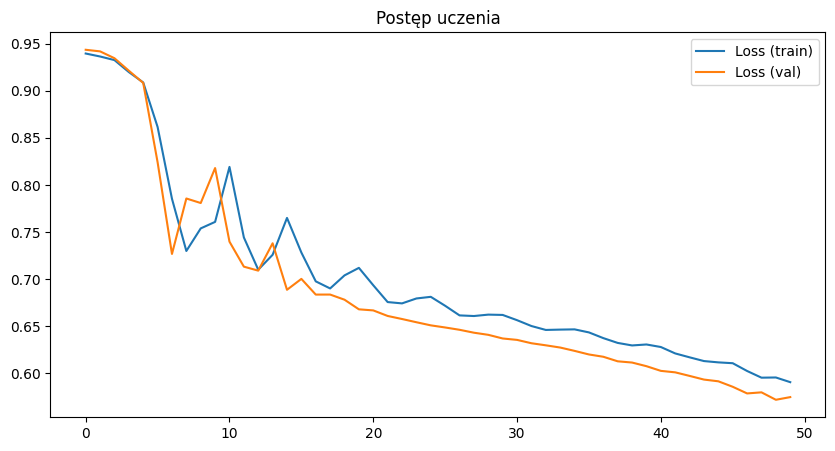

In [24]:
# trenowanie
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (val)')
plt.legend()
plt.title("Postęp uczenia")
plt.show()


WYNIKI WALIDACJI: IoU: 0.2787, F1: 0.4360, Precision: 0.3842, Recall: 0.5038


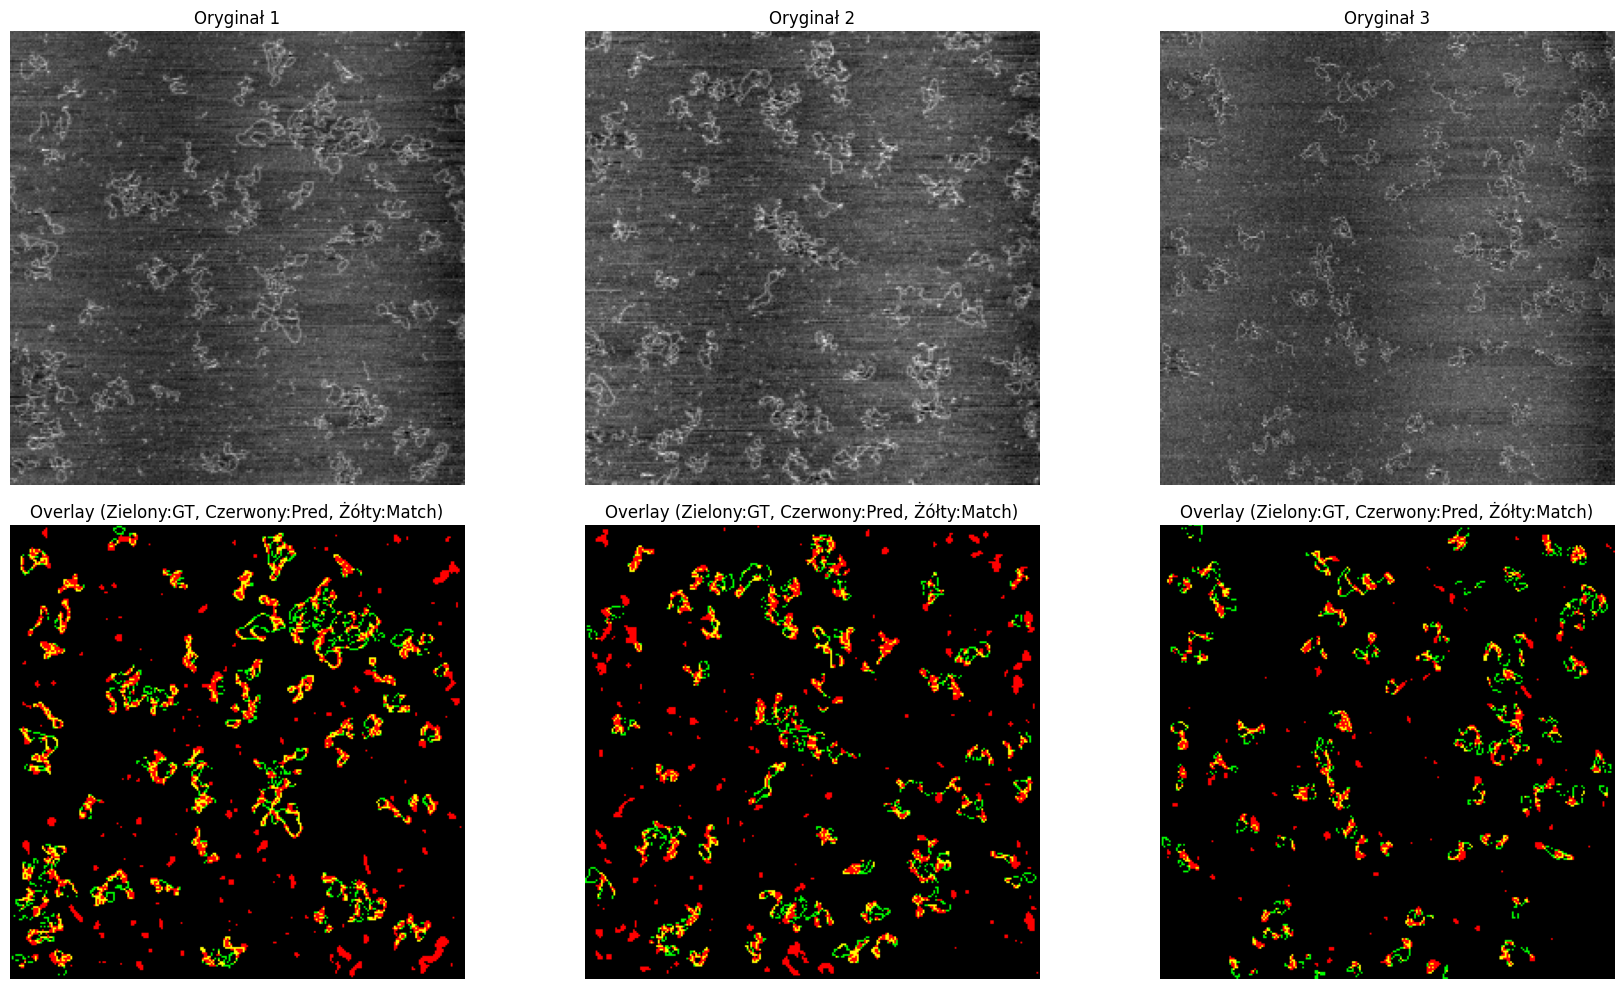

In [25]:
from sklearn.metrics import precision_recall_fscore_support

def evaluate_model(model, dataset):
    all_preds = []
    all_masks = []

    for imgs, masks in dataset:
        preds = model.predict(imgs, verbose=0)
        preds_bin = (preds > 0.5).astype(np.uint8)
        all_preds.append(preds_bin.flatten())
        all_masks.append(masks.numpy().flatten().astype(np.uint8))

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_masks)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    iou = intersection / union if union != 0 else 0

    print(f"\nWYNIKI WALIDACJI: IoU: {iou:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

# Uruchomienie ewaluacji
evaluate_model(model, val_ds)

# Wizualizacja nakładających się masek
for imgs, masks in val_ds.take(1):
    preds = model.predict(imgs, verbose=0)
    plt.figure(figsize=(18, 10))
    for i in range(min(len(imgs), 3)):
        # Przygotowanie obrazu nakładanego (RGB)
        true_mask = masks[i].numpy().squeeze()
        pred_mask = (preds[i].squeeze() > 0.5).astype(np.float32)

        # Tworzymy kolorowy overlay: Zielony = Prawda, Czerwony = Model
        overlay = np.zeros((*true_mask.shape, 3))
        overlay[..., 1] = true_mask  # Zielony kanał dla Ground Truth
        overlay[..., 0] = pred_mask  # Czerwony kanał dla Prediction
        # Żółty pojawi się tam, gdzie oba są 1

        plt.subplot(2, 3, i + 1)
        plt.imshow(imgs[i].numpy().squeeze(), cmap='gray')
        plt.title(f"Oryginał {i+1}")
        plt.axis('off')

        plt.subplot(2, 3, i + 4)
        plt.imshow(overlay)
        plt.title("Overlay (Zielony:GT, Czerwony:Pred, Żółty:Match)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

### 4. Zapisywanie modelu
Warto zapisać model na dysku Google, aby móc go wczytać później za pomocą `tf.keras.models.load_model()`.

In [26]:
model_save_path = os.path.join(main_folder, 'unet_plasmid_segmentation.keras')

# Zapisujemy model
model.save(model_save_path)

print(f"Model został zapisany pomyślnie w: {model_save_path}")

Model został zapisany pomyślnie w: /content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1/unet_plasmid_segmentation.keras


### 5. Predykcja na nowym zdjęciu
Poniższy blok pozwala na wczytanie zapisanego wcześniej modelu i wykonanie segmentacji na wybranym pojedynczym zdjęciu.

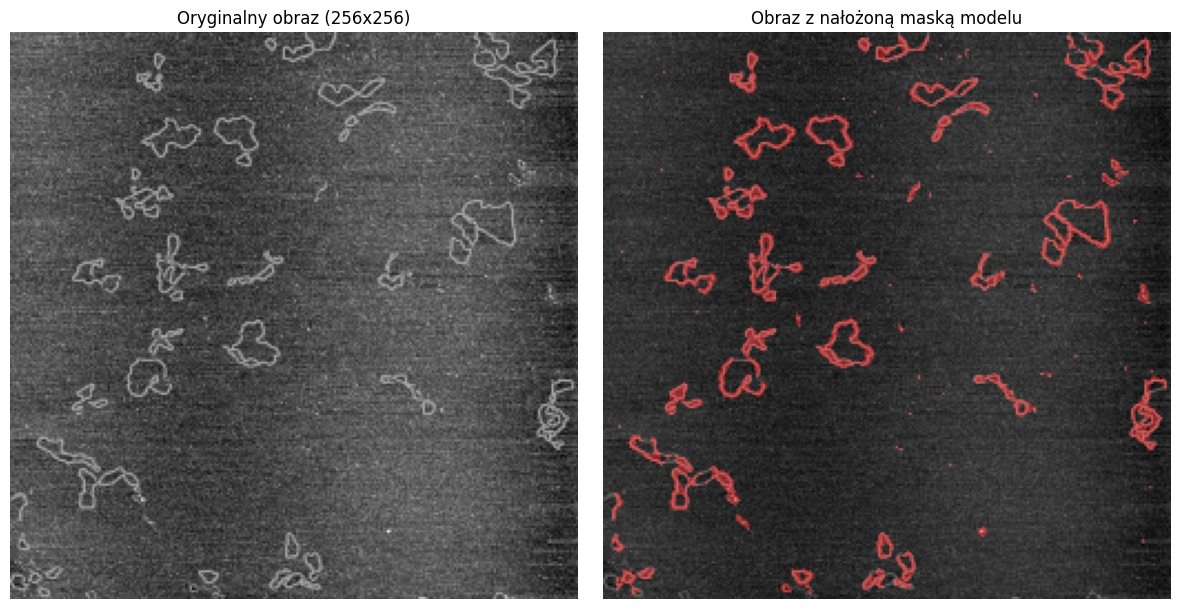

In [27]:
def predict_and_plot(img_path, model_path):
    # 1. Wczytanie modelu z uwzględnieniem custom loss
    custom_objects = {'dice_loss': dice_loss}
    loaded_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)

    # 2. Wczytanie i przygotowanie zdjęcia
    if not os.path.exists(img_path):
        print(f"BŁĄD: Plik nie istnieje pod ścieżką: {img_path}")
        return

    img_raw = tf.io.read_file(img_path)
    img_tensor = tf.image.decode_png(img_raw, channels=1)
    img_tensor = tf.image.convert_image_dtype(img_tensor, tf.float32)
    img_resized = tf.image.resize(img_tensor, [256, 256])

    # Dodanie wymiaru batcha (1, 256, 256, 1)
    input_batch = tf.expand_dims(img_resized, axis=0)

    # 3. Predykcja
    prediction = loaded_model.predict(input_batch, verbose=0)[0]
    pred_mask = (prediction > 0.5).astype(np.float32)

    # 4. Wizualizacja
    plt.figure(figsize=(12, 6))

    # Oryginał
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized.numpy().squeeze(), cmap='gray')
    plt.title("Oryginalny obraz (256x256)")
    plt.axis('off')

    # Overlay
    plt.subplot(1, 2, 2)
    overlay = np.zeros((*pred_mask.squeeze().shape, 3))
    # Nakładamy maskę w kolorze czerwonym
    overlay[..., 0] = pred_mask.squeeze()

    plt.imshow(img_resized.numpy().squeeze(), cmap='gray')
    plt.imshow(overlay, alpha=0.4)
    plt.title("Obraz z nałożoną maską modelu")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- TUTAJ WPISZ ŚCIEŻKĘ ---
#'/content/drive/MyDrive/TwojFolder/zdjecie.png'
manual_path = '/content/drive/MyDrive/exact_masks_results_vol1/exact_masks_results_vol1/25Gy_expert1/CONV_fot_25Gy1_nr2.0_00018.png'

model_save_path = os.path.join(main_folder, 'unet_plasmid_segmentation.keras')
predict_and_plot(manual_path, model_save_path)